# 🎫 IT Support Ticket Classification System

## Machine Learning Project using Natural Language Processing (NLP)

### Objective
The objective of this project is to automatically classify IT support tickets into their respective categories using Natural Language Processing (NLP) and Machine Learning techniques.

#  Step 1: Import Required Libraries

In this step, all required libraries for data analysis, visualization, text processing, and machine learning are imported.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

#  Step 2: Load Dataset

The dataset is loaded into a Pandas DataFrame for further preprocessing and analysis.

In [2]:
df = pd.read_csv("all_tickets_processed_improved_v3.csv")

df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


#  Step 3: Explore Dataset

Understanding the dataset structure, number of records, and available features.

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n")
print(df.columns)

df.info()

Dataset Shape: (47837, 2)

Columns:

Index(['Document', 'Topic_group'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 373.8+ KB


#  Step 4: Check Missing Values

Missing values are identified to ensure data quality before model training.

In [4]:
print(df.isnull().sum())

Document       0
Topic_group    0
dtype: int64


#  Step 5: Select Features

Input Feature:
- Document

Target Variable:
- Topic_group

In [5]:
X = df['Document']

y = df['Topic_group']

#  Step 6: Exploratory Data Analysis (EDA)

Analyzing the distribution of ticket categories.

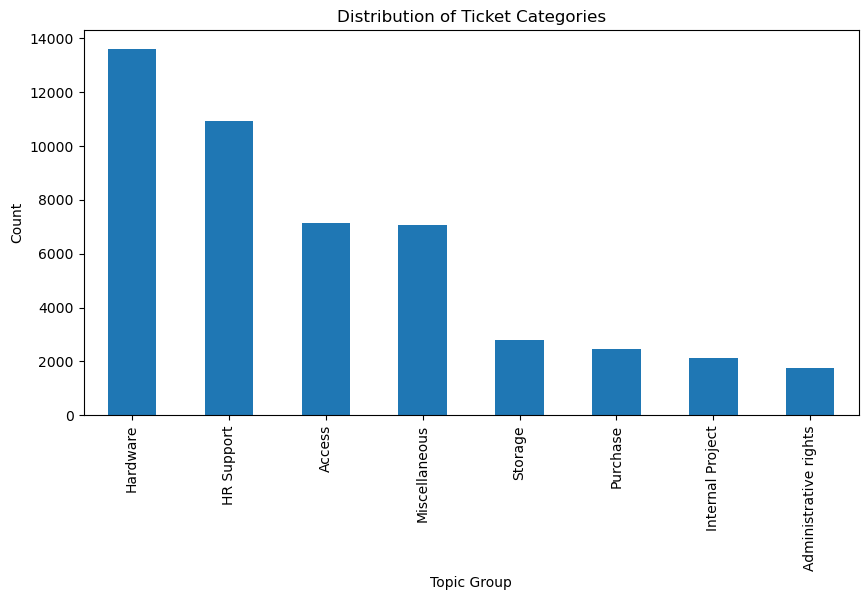

In [6]:
df['Topic_group'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Distribution of Ticket Categories")

plt.xlabel("Topic Group")

plt.ylabel("Count")

plt.show()

#  Step 7: Convert Text into Numerical Features

TF-IDF Vectorization converts textual ticket descriptions into numerical feature vectors suitable for machine learning algorithms.

In [7]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X)

print(X_tfidf.shape)

(47837, 5000)


#  Step 8: Split Dataset

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

#  Step 9: Train Logistic Regression Model

A Logistic Regression model is trained to classify support tickets into their respective categories.

In [10]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

print("=" * 50)
print("MODEL TRAINING COMPLETED SUCCESSFULLY")
print("=" * 50)

print("Algorithm Used : Logistic Regression")
print("Maximum Iterations :", model.max_iter)

MODEL TRAINING COMPLETED SUCCESSFULLY
Algorithm Used : Logistic Regression
Maximum Iterations : 1000


#  Step 10: Generate Predictions

The trained model predicts ticket categories for the test dataset.

In [11]:
y_pred = model.predict(X_test)

#  Step 11: Evaluate Model Performance

Model performance is evaluated using:
- Accuracy Score
- Precision
- Recall
- F1 Score

In [12]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.845108695652174
                       precision    recall  f1-score   support

               Access       0.91      0.87      0.89      1455
Administrative rights       0.87      0.68      0.77       342
           HR Support       0.84      0.83      0.84      2107
             Hardware       0.79      0.88      0.83      2760
     Internal Project       0.91      0.80      0.85       451
        Miscellaneous       0.80      0.82      0.81      1400
             Purchase       0.97      0.88      0.92       497
              Storage       0.93      0.84      0.88       556

             accuracy                           0.85      9568
            macro avg       0.88      0.82      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



#  Step 12: Confusion Matrix

A confusion matrix is used to visualize the classification performance across all ticket categories.

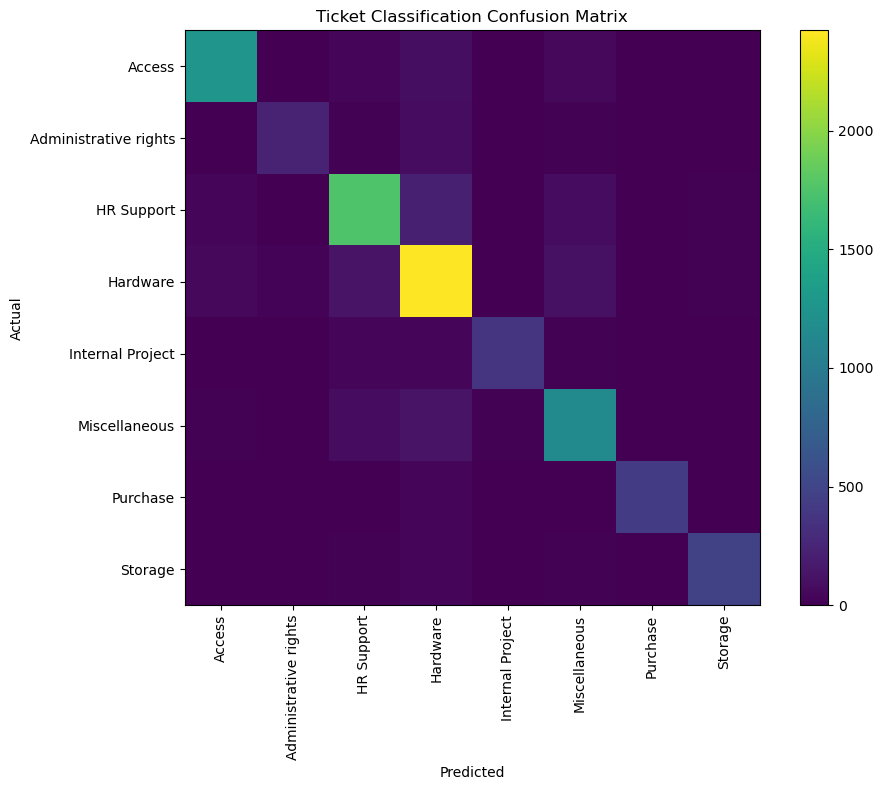

In [13]:
labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Ticket Classification Confusion Matrix"
)

plt.tight_layout()

plt.show()

#  Step 13: Real-Time Ticket Classification

A sample support ticket is provided to demonstrate how the trained model can classify new tickets automatically.

In [14]:
sample_ticket = [
    "Unable to login into my account and reset password."
]

sample_vector = tfidf.transform(
    sample_ticket
)

prediction = model.predict(
    sample_vector
)

print(
    "Predicted Category:",
    prediction[0]
)

Predicted Category: Access


# Conclusion

## Project Summary

This project successfully demonstrates the use of Natural Language Processing (NLP) and Machine Learning techniques for automating support ticket classification.

Support ticket descriptions were preprocessed and converted into numerical representations using TF-IDF Vectorization. Logistic Regression models were then trained to classify tickets into different topic groups and priority levels.

## Key Achievements

✔ Cleaned and preprocessed textual ticket data

✔ Performed Exploratory Data Analysis (EDA)

✔ Converted ticket text into numerical features using TF-IDF

✔ Built a Topic Group Classification model

✔ Generated and classified ticket priorities

✔ Evaluated model performance using Accuracy Score, Classification Report, and Confusion Matrix

✔ Developed an automated ticket categorization workflow

## Outcome

The developed system can automatically classify customer support tickets and assign priority levels, helping organizations reduce manual effort, improve response times, and streamline customer support operations.

This project demonstrates the practical application of Machine Learning in customer service and ticket management systems.